# 6. HW_L04_01_Deep_Learning

# 1. Basic Concepts and Tensor Operations

Before implementing deep learning models, it is essential to be familiar with the basic data structures (tensors) and the mathematical operations performed on them.

## Tensor Dimension Management and Reshaping

A large portion of programming errors in deep learning comes from mismatched matrix dimensions.

1. Create a synthetic tensor named `images` with the following dimensions:
   `(Batch_Size=32, Channels=3, Height=64, Width=64)`

   Create it so that it displays a batch of colorful images.

2. Reshape the tensor so that it is ready to be fed into a fully connected layer.
   The output shape should be `(32, 12288)`.

   (Note: `12288 = 64 × 64 × 3`)

3. Change the order of the dimensions for visualization with `Matplotlib`:
   `(Height, Width, Channels)`

   Use it in situations where libraries expect data in PyTorch format:
   `(Channels, Height, Width)`

   To do this, use the `permute()` method first, and make sure the final shape is `(64, 64, 3)`.


In [1]:
import os

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

1. Create a synthetic tensor named `images` with the following dimensions:
   `(Batch_Size=32, Channels=3, Height=64, Width=64)`

In [3]:
torch.manual_seed(42) # Fixed random
images = torch.rand(32, 3, 64, 64)
print(images.shape)

torch.Size([32, 3, 64, 64])


2. Reshape the tensor so that it is ready to be fed into a fully connected layer.
   The output shape should be `(32, 12288)`.

   (Note: `12288 = 64 × 64 × 3`)


In [44]:
flatten_images = torch.flatten(images, start_dim=1)
print(flatten_images.shape)

torch.Size([32, 12288])


In [49]:
images[0]

tensor([[[0.8823, 0.9150, 0.3829,  ..., 0.1587, 0.6542, 0.3278],
         [0.6532, 0.3958, 0.9147,  ..., 0.2083, 0.3289, 0.1054],
         [0.9192, 0.4008, 0.9302,  ..., 0.5535, 0.4117, 0.3510],
         ...,
         [0.1457, 0.1499, 0.3298,  ..., 0.9624, 0.6400, 0.7409],
         [0.1709, 0.5797, 0.6340,  ..., 0.6885, 0.2405, 0.5956],
         [0.9199, 0.1247, 0.3573,  ..., 0.6752, 0.2058, 0.5027]],

        [[0.1458, 0.9024, 0.9217,  ..., 0.1868, 0.6352, 0.8431],
         [0.9549, 0.4435, 0.6924,  ..., 0.1168, 0.7160, 0.5462],
         [0.1616, 0.1054, 0.8614,  ..., 0.4531, 0.4736, 0.9448],
         ...,
         [0.4309, 0.3986, 0.1907,  ..., 0.9444, 0.2848, 0.3776],
         [0.7948, 0.6855, 0.1009,  ..., 0.6147, 0.7747, 0.2323],
         [0.5840, 0.9795, 0.3277,  ..., 0.3549, 0.1263, 0.1280]],

        [[0.5027, 0.4195, 0.8893,  ..., 0.3084, 0.1567, 0.7860],
         [0.7310, 0.9307, 0.2847,  ..., 0.8432, 0.8307, 0.0897],
         [0.7021, 0.5967, 0.7744,  ..., 0.8485, 0.4520, 0.

In [48]:
flatten_images[0]

tensor([0.8823, 0.9150, 0.3829,  ..., 0.5368, 0.2389, 0.2095])

3. Change the order of the dimensions for visualization with `Matplotlib`:
   `(Height, Width, Channels)`

   Use it in situations where libraries expect data in PyTorch format:
   `(Channels, Height, Width)`

   To do this, use the `permute()` method first, and make sure the final shape is `(64, 64, 3)`.


Plot image number of 1 :


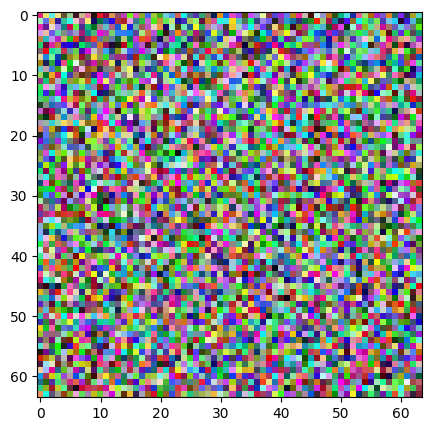

In [41]:
fig, ax = plt.subplots(figsize=(5, 5))
number_of_image = 0
print(f"Plot image number of {number_of_image + 1} :")
img = images[number_of_image].permute(1, 2, 0) # C,H,W change to H,W,C
ax.imshow(img);


### All Plot 

Create a subplot grid with dimensions $4 \times 8 = 32$:  

`fig, axes = plt.subplots(4, 8, figsize=(16, 8))`

---

The plot index is determined by `i`, obtained via `enumerate`. Since there are 32 images, `i` ranges from 0 to 31.
By using `axes.flat`, we replace two nested loops with a single loop to iterate through the subplot positions.   

---

In the `matplotlib` package, drawing an image requires the order `(Height, Width, Channels)`. However, in the tensor, the order is `(Channels, Height, Width)`. Therefore, we must swap the dimensions using the `permute` command:   

`img = images[i].permute(1, 2, 0)`

---

Each image is then plotted:   

`ax.imshow(img)`

---

Since the axes are not meaningful in this context, they are disabled:   

`ax.axis("off")`

---

Finally, we adjust the layout to be standardized:    

`plt.tight_layout()`


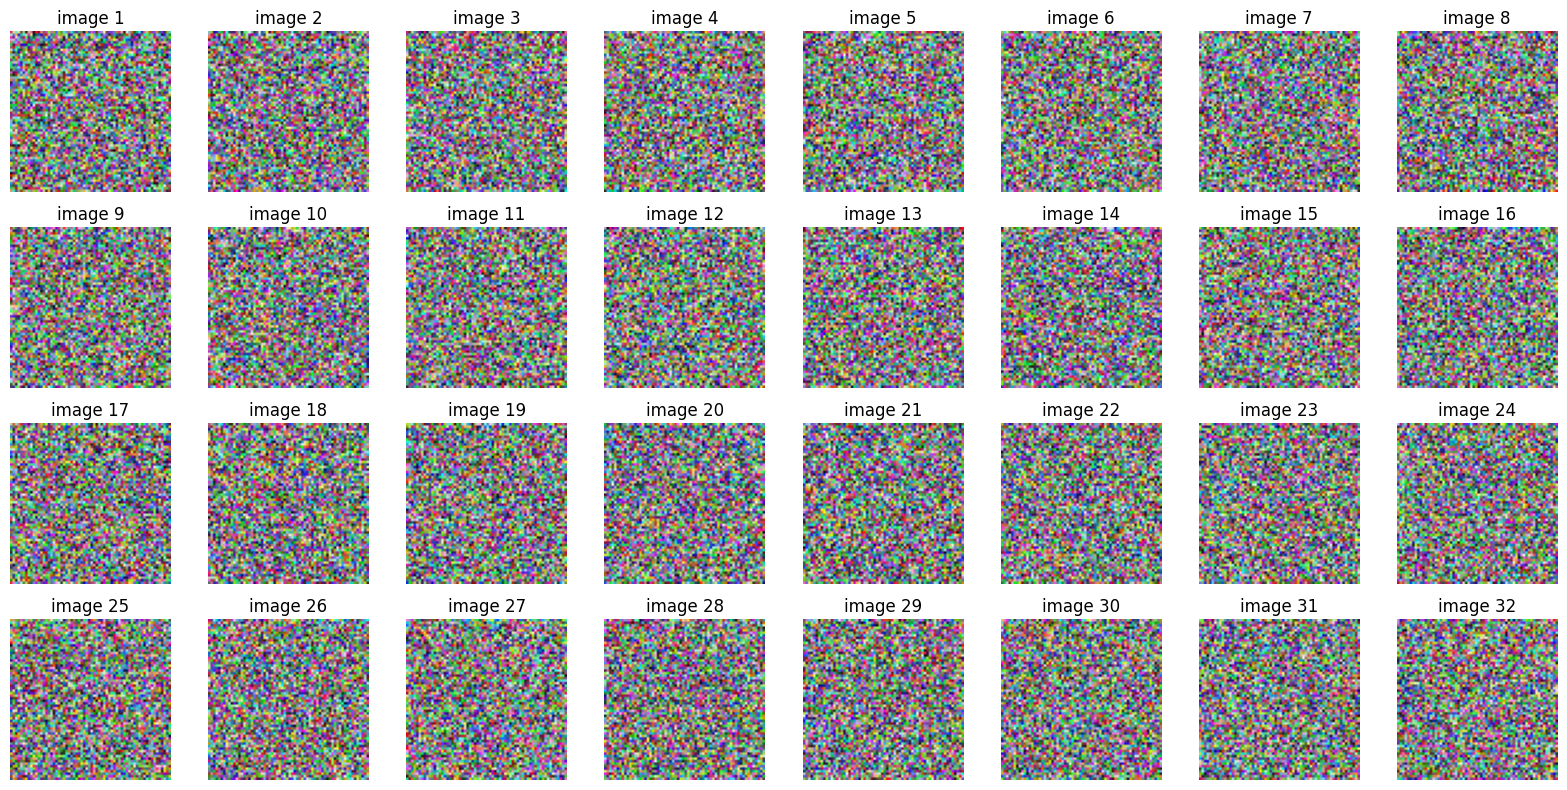

In [43]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat): # axes.flat = row 4 and column 8

    img = images[i].permute(1, 2, 0)  # C,H,W change to H,W,C
    # (3 channel, 64 hight, 64 width) change to (64 hight, 64 width, 33 channel)

    ax.imshow(img)
    ax.set_title(f"image {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Automatic Gradient Computation

1. Define the variable `x` as a tensor with the value `2.0` and enable `requires_grad=True` for it.
2. Implement the function  $y = x^3 + 5x^2 + 2$

3. Manually compute the derivative $\frac{dy}{dx}$ at `x = 2`.
4. Use the `backward()` method on $y$ to compute the gradient, then print the value of `x.grad`. Compare the result with your manual calculation.

With this, we want to compute the gradient.



1. Define the variable `x` as a tensor with the value `2.0` and enable `requires_grad=True` for it.

`requires_grad=True` tells PyTorch:

"Track this tensor for gradient computation."

In other words, if you perform operations on this tensor, PyTorch keeps track of those operations in the computational graph so that you can later compute derivatives using `backward()`.


In [66]:
x = torch.tensor(2.0, requires_grad=True)
print(x)

tensor(2., requires_grad=True)


2. Implement the function  $y = x^3 + 5x^2 + 2$


In [67]:
y = x**3 + 5*(x**2) + 2
print(y)

tensor(30., grad_fn=<AddBackward0>)


3. Manually compute the derivative $\frac{dy}{dx}$ at `x = 2`.

Manual Calculation

First, we differentiate the function

$$
y = x^3 + 5x^2 + 2
$$

with respect to $x$:

$$
\frac{dy}{dx} = 3x^2 + 10x
$$

Now substitute $x = 2$:

$$
\left.\frac{dy}{dx}\right|_{x=2} = 3(2)^2 + 10(2) = 3(4) + 20 = 12 + 20 = 32
$$

In [57]:
y_x = 3*(x**2) + 10*x
print(f"gradiant dy/dx [x=2] = {y_x}")

gradiant dy/dx [x=2] = 32.0


4. Use the `backward()` method on $y$ to compute the gradient, then print the value of `x.grad`. Compare the result with your manual calculation.

In [77]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 5*(x**2) + 2
print(f"x is {x} and y is {y}")
y_x = 3*(x**2) + 10*x
print(f"manual gradiant dy/dx [x=2] = {y_x}")
y.backward()
print(f"by backward dy/dx [x=2] =     {x.grad.item()}")

x is 2.0 and y is 30.0
manual gradiant dy/dx [x=2] = 32.0
by backward dy/dx [x=2] =     32.0
